# Introducción a K-Means

Este notebook está pensado para **estudiar el algoritmo K-Means paso a paso** usando un dataset de familias con **ingresos, gastos y ahorro**.

## Indicaciones
Intenta responder a estos puntos.
- Comprender qué problema resuelve K-Means.
- Explorar el dataset antes de agrupar.
- Seleccionar variables con criterio.
- Entender por qué hay que escalar los datos.
- Aplicar K-Means con distintos valores de `k`.
- Utilizar el método Elbow (del codo)
- Interpretar los centroides y los clusters.

> Nota: comenta cada resultado antes de pasar a la siguiente.

## 1. Cargar librerías y dataset

En esta primera parte cargamos:
- el dataset de familias,
- las librerías de análisis,
- y una vista inicial de los datos.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [56]:
# Cambia la ruta si guardas el CSV en otra carpeta
df = pd.read_csv("05_familias_gastos_ingresos_300.csv", sep= ",")
df.head()

,id_hogar,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,1,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,2,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,3,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,4,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,5,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


## 2. Primer vistazo al dataset

Antes de usar cualquier algoritmo, hay que entender los datos:
- cuántas filas hay,
- qué variables tenemos,
- si hay valores nulos,
- y qué magnitudes manejamos.

In [57]:
#filas
df.count()

id_hogar              300
ingreso_anual         300
gasto_vivienda        300
gasto_alimentacion    300
gasto_transporte      300
gasto_ocio            300
gasto_salud           300
gasto_educacion       300
ahorro                300
dtype: int64

In [58]:
#variables

# Viendo el info, podemos ver que todas las variables son numéricas.

In [59]:
#cómo son los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_hogar            300 non-null    int64  
 1   ingreso_anual       300 non-null    float64
 2   gasto_vivienda      300 non-null    float64
 3   gasto_alimentacion  300 non-null    float64
 4   gasto_transporte    300 non-null    float64
 5   gasto_ocio          300 non-null    float64
 6   gasto_salud         300 non-null    float64
 7   gasto_educacion     300 non-null    float64
 8   ahorro              300 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 21.2 KB


In [60]:
#hay nulos o no
df.isna().sum()

id_hogar              0
ingreso_anual         0
gasto_vivienda        0
gasto_alimentacion    0
gasto_transporte      0
gasto_ocio            0
gasto_salud           0
gasto_educacion       0
ahorro                0
dtype: int64

## 3. Comprender el problema

K-Means es un algoritmo de **aprendizaje no supervisado**.
Eso significa que:
- no hay una columna objetivo,
- no hay etiquetas previas,
- y el objetivo es **descubrir grupos similares** en los datos.

En este caso queremos detectar perfiles de familias, por ejemplo:
- Familia tipo 1: .....
- Familia tipo 2: .....
- Familia tipo 3: .....

In [61]:
# Podemos ver la correlacion con ahorro
df.corr(numeric_only=True).abs()["ahorro"].sort_values(ascending=False)

ahorro                1.000000
ingreso_anual         0.767514
gasto_vivienda        0.652076
gasto_alimentacion    0.651607
gasto_salud           0.529094
gasto_transporte      0.496608
gasto_educacion       0.380107
gasto_ocio            0.296066
id_hogar              0.008192
Name: ahorro, dtype: float64

## 4. Selección inicial de variables

No siempre interesa usar todas las columnas desde el principio.
Para empezar, vamos a observar una relación muy intuitiva:

- `ingreso_anual`
- `gasto_ocio`

Esto permite una primera visualización sencilla del problema.

In [62]:
X_simple = df[["ingreso_anual", "gasto_ocio"]]
X_simple.head()

,ingreso_anual,gasto_ocio
0,35319.00,4041.16
1,53484.00,3031.31
2,50007.61,3666.31
3,39437.43,3600.76
4,12000.00,840.63


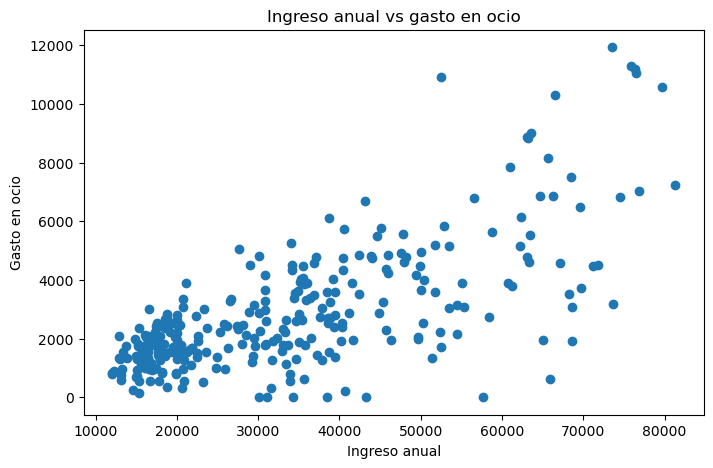

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(df["ingreso_anual"], df["gasto_ocio"])
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("Ingreso anual vs gasto en ocio")
plt.show()

### Cuestiones
1. ¿Se distinguen grupos visualmente?
    - Sí, se pueden intuir varios grupos de familias. Se observa una tendencia donde las familias con menores ingresos suelen gastar menos en ocio, y los que ingresan más gastan más.
2. ¿Parece haber familias con ingresos parecidos pero distinto gasto en ocio?
    - Si, ya que no todas las familias tienen los mismos habitos ni consumen lo mismo, también por esto hay familias más derrochadoras y más ahorradoras.
3. ¿Crees que con solo dos variables será suficiente?
    - No, porque no solo hay gastos de ocio, sino que tambien hay otro tipo de gastos los cuales también son de relevancia y describirian mejor los perfiles entre familias

## 5. Primer K-Means con `k = 3`

Empieza con una prueba sencilla.
Aquí el algoritmo:
1. Fija un número de grupos `k`,
2. Busca centroides,
3. Asigna cada familia al centroide más cercano.

In [64]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_simple)

labels_3 = kmeans_3.labels_
centroides_3 = kmeans_3.cluster_centers_

print("Centroides:")
print(centroides_3)

Centroides:
[[18685.46454545  1672.61075758]
 [63753.68980769  5573.08115385]
 [37749.7662069   2994.94077586]]


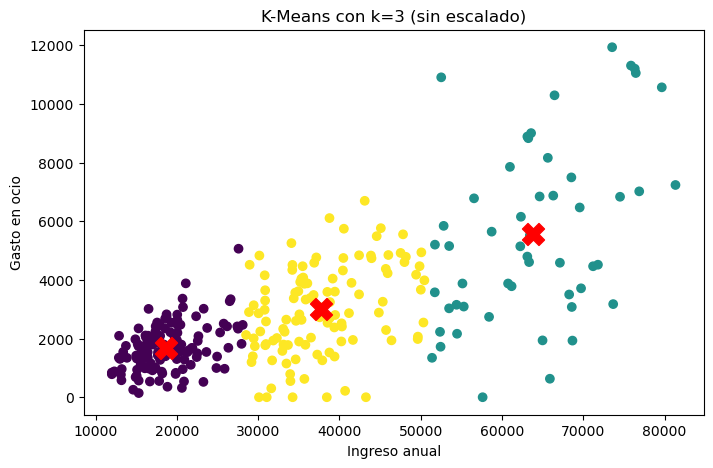

In [65]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=labels_3)
plt.scatter(centroides_3[:,0], centroides_3[:,1], marker="X", c="red", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("K-Means con k=3 (sin escalado)")
plt.show()

## 6. Interpretar los centroides

Los centroides representan el “centro” de cada grupo.

Conviene pasarlos a tabla para interpretarlos mejor.

In [66]:
pd.DataFrame(centroides_3, columns=X_simple.columns)

,ingreso_anual,gasto_ocio
0,18685.464545,1672.610758
1,63753.689808,5573.081154
2,37749.766207,2994.940776


### Cuestione
1. ¿Qué clúster tiene el mayor ingreso medio?
    - El cluster que tiene mayor ingreso medio, es el centroide número 1, ya que este cuenta con un ingreso anual de 63k.
2. ¿Cuál tiene menor gasto en ocio?
    - El que tiene menor gasto en ocio, pertenece al centroide número 0, ya que este es el que menor ingresos tiene, con lo cual tiene menos cantidad para gastar.
3. ¿Cómo describirías cada grupo con palabras?
    - El primer centroide es aquel grupo de personas los cuales generan menos ingresos, pero también gastan menos, con lo cual llevan un perfil bajo. El segundo centroide es el que mas ingresos tiene, con lo cual tiene mayores gastos de ocio porque se lo puede permitir. Y el último centroide es aquel de perfil medio, es aquel que tiene una cantidad buena de ingresos, pero tiene gastos en ocio moderados.

    Hay que tener en cuenta, que no es directamente proporcional los ingresos con el gasto en ocio, ya que este puede subir levemente pero no de la misma manera que sube el sueldo.

## 7. Probar distintos valores de `k`

K-Means necesita que indiques el número de grupos.
Repite el proceso con distintos valores para ver cómo cambia el resultado.

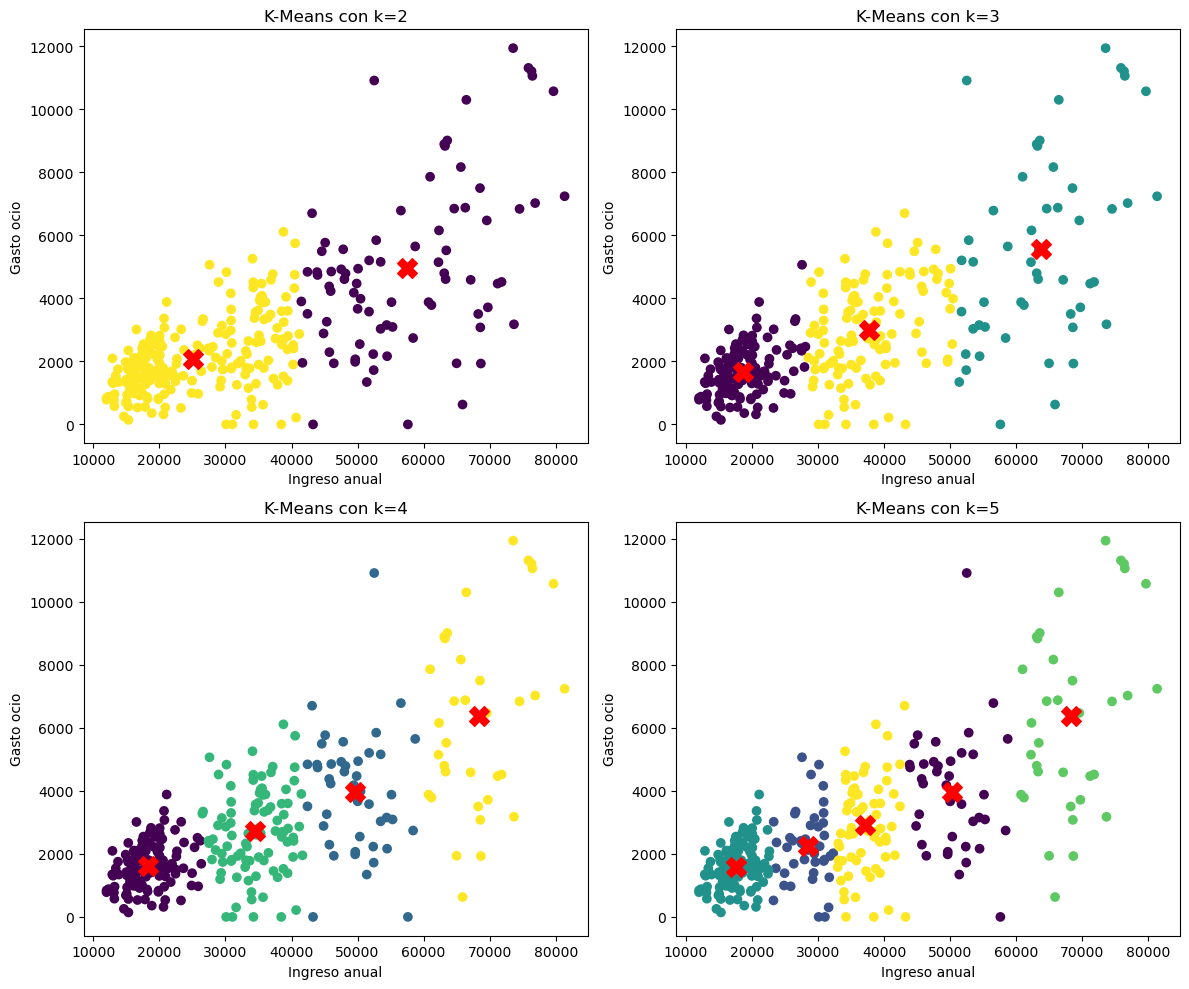

In [67]:
valores_k = [2, 3, 4, 5]

plt.figure(figsize=(12, 10))

for i, k in enumerate(valores_k, start=1):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_simple)
    centros = modelo.cluster_centers_

    plt.subplot(2, 2, i)
    plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=etiquetas)
    plt.scatter(centros[:,0], centros[:,1], marker="X", c="red", s=200)
    plt.title(f"K-Means con k={k}")
    plt.xlabel("Ingreso anual")
    plt.ylabel("Gasto ocio")

plt.tight_layout()
plt.show()

## 8. Método Elbow (Método del codo)

Una forma clásica de elegir `k` es calcular la **inercia** para distintos valores.
La inercia mide, en términos simples, lo compactos que quedan los grupos.

Buscamos el punto en que la mejora deja de ser tan grande.

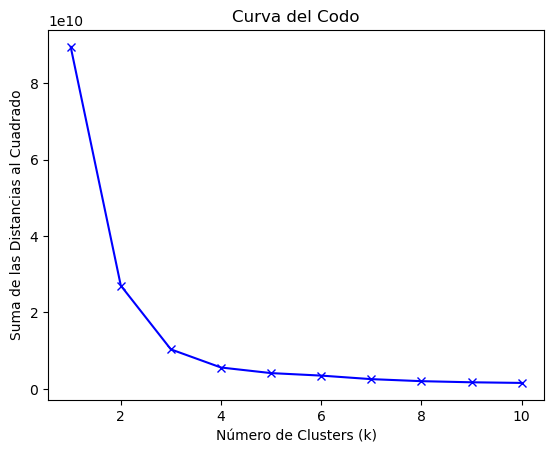

In [68]:
# Método Elbow - Codo
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def elbow_method(data, max_clusters=10):

    # Calcular la suma de las distancias al cuadrado para cada número de clusters
    # - data: es el conjunto de datos a clusterizar (X_simple)
    # - max_clusters: es el número máximo de clusters a evaluar (10)

    sum_of_squared_distances = []

    for k in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        sum_of_squared_distances.append(kmeans.inertia_)

    # Graficar la curva del codo
    plt.plot(range(1, max_clusters+1), sum_of_squared_distances, 'bx-')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Suma de las Distancias al Cuadrado')
    plt.title('Curva del Codo')
    plt.show()

elbow_method(X_simple, max_clusters=10)

### Cuestiones
1. ¿En qué valor de `k` parece estar el “codo”?
    - Yo diria, que el valor óptimo de K es 3. Ya que es el punto el cual la suma de las distancias ya no aumenta de forma sustancial, esta es la finalidad principal del método del codo
2. ¿Ese valor coincide con lo que observabas en la gráfica?
    - Si, porque se ve que no tiene sentido seguir desglosandolo en más "grupos"
3. ¿Crees que hay una única respuesta correcta?
    - No hay una respuesta correcta, ya que muchas veces hay que entender cada dato, es decir, hay datos los cuales conviene hacer más grupos y en otros no

## 9. ¿Por qué es importante escalar?

K-Means trabaja con distancias.
Si una variable tiene valores mucho más grandes que otra, dominará el resultado.

Lo puedes comprobar ampliando las variables:
- ingresos,
- varios tipos de gasto,
- ahorro.

In [69]:
columnas_modelo = [
    "ingreso_anual",
    "gasto_vivienda",
    "gasto_alimentacion",
    "gasto_transporte",
    "gasto_ocio",
    "gasto_salud",
    "gasto_educacion",
    "ahorro"
]

X = df[columnas_modelo]
X.head()

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


In [70]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
ingreso_anual,300.0,33868.820233,17169.230976,12000.00,18733.9400,30962.135,43409.1550,81330.33
gasto_vivienda,300.0,10126.577700,5234.255944,3187.00,5650.7275,9284.880,13350.4350,24990.75
gasto_alimentacion,300.0,6260.093467,3430.261648,1885.87,3411.5100,5600.565,8076.6900,17029.32
gasto_transporte,300.0,3399.638000,2017.642022,655.81,1834.5550,2815.020,4635.6850,11019.70
gasto_ocio,300.0,2859.993233,2149.923506,0.00,1447.8325,2266.845,3805.7775,11935.32
gasto_salud,300.0,2008.935567,1284.444677,0.00,1141.7275,1685.030,2523.5525,7893.35
gasto_educacion,300.0,2383.226000,1634.672553,0.00,1264.5775,1989.195,3086.0750,9547.87
ahorro,300.0,6830.356533,4589.870824,-1084.03,3449.3725,5539.920,9734.2025,25817.67


Observa que:
- `ingreso_anual` tiene una magnitud muy superior,
- y algunas variables de gasto tienen escalas bastante distintas.

Por eso vamos a comparar el clustering:
1. **sin escalado**
2. **con escalado**

In [71]:
modelo_sin_escalar = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sin_escalar = modelo_sin_escalar.fit_predict(X)

df["cluster_sin_escalar"] = labels_sin_escalar
df.groupby("cluster_sin_escalar")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_sin_escalar,,,,,,,,
0,36687.48,11021.95,6686.03,3819.94,2944.20,2163.72,2574.52,7477.13
1,61909.99,18339.81,11673.12,5979.66,5293.97,3645.94,4334.50,12642.99
2,18541.72,5578.23,3401.37,1853.22,1665.37,1122.42,1320.78,3600.33


In [72]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

modelo_escalado = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_escalado = modelo_escalado.fit_predict(X_escalado)

df["cluster_escalado"] = labels_escalado
df.groupby("cluster_escalado")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_escalado,,,,,,,,
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


## 10. Comparación de resultados

Ahora compara las medias de cada cluster:
- ¿Son más coherentes tras escalar?
    - Sí, despues de escalar los datos, todas las variables tienen un peso similar en el cálculo de distancias, por lo que los clusters representan mejor.
- ¿Parece que el modelo recoge mejor el comportamiento global de las familias?
    - Sí, porque se evita que aquellas variables con valores muy grandes (ingresos) acaparen todo el clustering.

In [73]:
print("Distribución de familias por cluster (sin escalar):")
print(df["cluster_sin_escalar"].value_counts().sort_index())

print("\nDistribución de familias por cluster (escalado):")
print(df["cluster_escalado"].value_counts().sort_index())

Distribución de familias por cluster (sin escalar):
cluster_sin_escalar
0    110
1     60
2    130
Name: count, dtype: int64

Distribución de familias por cluster (escalado):
cluster_escalado
0     51
1    130
2    119
Name: count, dtype: int64


## 11. Centroides del modelo escalado

Como los centroides escalados son difíciles de interpretar directamente,
vamos a devolverlos a la escala original.

In [74]:
centroides_escalados = modelo_escalado.cluster_centers_
centroides_originales = scaler.inverse_transform(centroides_escalados)

pd.DataFrame(centroides_originales, columns=columnas_modelo).round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


### Cuestiones
1. ¿Qué clúster representa familias con más ingresos?
    - El clúster que representa familias con más ingresos el es clúster 0 con un ingreso anual de unos 63k
2. ¿Qué clúster parece más vulnerable?
    - El clúster que parece más vulnerable es aquel que cuenta con menores ingresos por lo general, aunque puede haber familias mas ahorradoras y derrochadoras. Igualmente este es el clúster 1, con unos ingresos de 18k
3. ¿Cuál parece más ahorrador?
    - Aparentemente el cluster más ahorrador es aquel que cuenta con mayores ingresos anuales, no solo porque ganen más sino que cuentan con gran ahorro y eso que cuentan con grandes gastos
4. ¿Ves relación entre ingresos altos y mayor gasto en algunas categorías?
    - Sí, los hogares con mayores ingresos también presentan mayores gastos en categorías como vivienda, ocio o educación, lo que refleja un mayor nivel de consumo

## 12. Interpretación final de clusters

Redacta una interpretación breve de cada cluster.

Modelo de ejemplo:

- **Cluster A**: es una familia con ingresos altos (familias adineradas), los cuales cuentan con mayores gastos, pero que debido a sus altos ingresos son capaces de seguir aumentando el ahorro de forma sustancial.
- **Cluster B**: es una familia de ingresos bajos (familias vulnerables), los cuales tienen menos gastos, pero aun asi, son menos conservadores, ya que en proporción no son capaces de ahorrar tanto dinero (algo derrochadoras).
- **Cluster C**: es una familia de ingresos medios (familias acomodadas), los cuales cuentan con una series de gastos medios, pero estos si que son muy capaces de ahorrar en base a la cantidad de gastos y los ingresos.

Lo importante no es solo ejecutar K-Means, sino **dar sentido a los grupos**.

## 13. Actividad de ampliación

Prueba alguna de estas variantes:
- usar solo ingresos y ahorro,
- usar ingresos, vivienda, alimentación y ocio,
- probar `k = 4`,
- comparar resultados con y sin la variable `ahorro`,
- detectar si algunos hogares quedan en clusters poco claros.

Esto te ayudará a entender que en Aprendizaje No Supervisado las decisiones sobre variables y preparación de datos cambian el resultado.
> Resumiendo: K-Means no “descubre la verdad”; propone agrupaciones a partir de cómo le damos los datos.

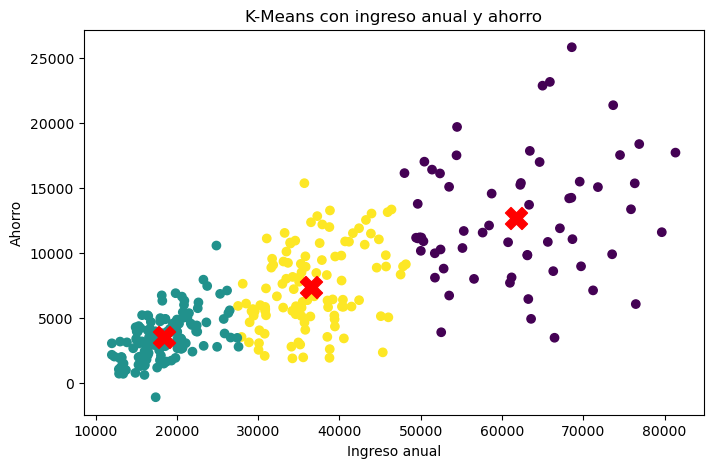

In [75]:
# Vamos a probar solo tomando ingresos y ahorro
X_ingreso_ahorro = df[["ingreso_anual", "ahorro"]]
X_ingreso_ahorro.head()

modelo_ingreso_ahorro = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_ingreso_ahorro = modelo_ingreso_ahorro.fit_predict(X_ingreso_ahorro)

df["cluster_ingreso_ahorro"] = labels_ingreso_ahorro
df.groupby("cluster_ingreso_ahorro")[["ingreso_anual", "ahorro"]].mean().round(2)

# Representación gráfica de los clusters con ingreso anual y ahorro
plt.figure(figsize=(8,5))
plt.scatter(X_ingreso_ahorro["ingreso_anual"], X_ingreso_ahorro["ahorro"], c=labels_ingreso_ahorro)
centros_ingreso_ahorro = modelo_ingreso_ahorro.cluster_centers_
plt.scatter(centros_ingreso_ahorro[:,0], centros_ingreso_ahorro[:,1], marker="X", c="red", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Ahorro")
plt.title("K-Means con ingreso anual y ahorro")
plt.show()

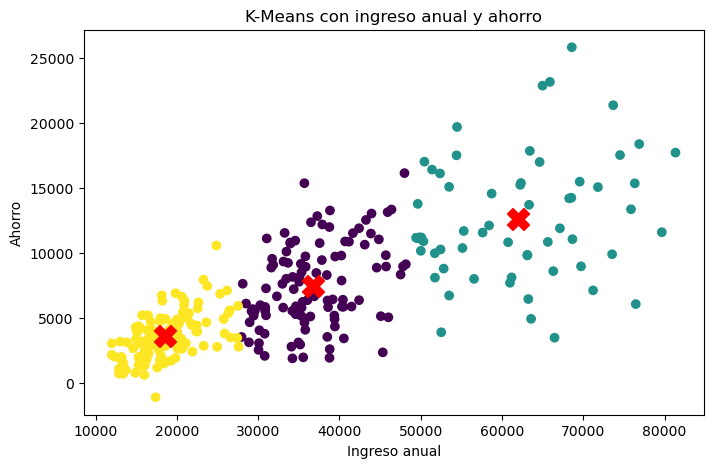

In [76]:
# Vamos a probar solo tomando ingresos, vivienda, alimentación y ocio
X_ingreso_vivienda = df[["ingreso_anual", "ahorro", "gasto_vivienda", "gasto_alimentacion", "gasto_ocio"]]
X_ingreso_vivienda.head()

modelo_ingreso_vivienda = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_ingreso_vivienda = modelo_ingreso_vivienda.fit_predict(X_ingreso_vivienda)

df["cluster_ingreso_vivienda"] = labels_ingreso_vivienda
df.groupby("cluster_ingreso_vivienda")[["ingreso_anual", "ahorro"]].mean().round(2)

# Representación gráfica de los clusters con ingreso anual y ahorro
plt.figure(figsize=(8,5))
plt.scatter(X_ingreso_vivienda["ingreso_anual"], X_ingreso_vivienda["ahorro"], c=labels_ingreso_vivienda)
centros_ingreso_vivienda = modelo_ingreso_vivienda.cluster_centers_
plt.scatter(centros_ingreso_vivienda[:,0], centros_ingreso_vivienda[:,1], marker="X", c="red", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Ahorro")
plt.title("K-Means con ingreso anual y ahorro")
plt.show()

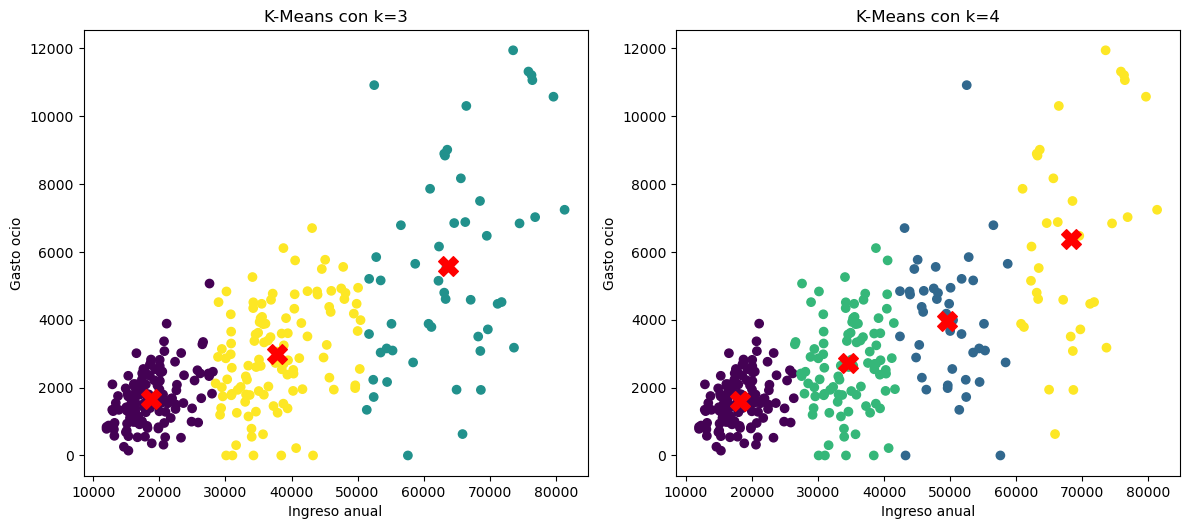

In [ ]:
# Valorando entre k=3 y 4. Se puede comprobar que la mejor agrupación es con k=3, ya que con k=4 se forma un cluster muy pequeño (cluster 3) con solo 8 familias, 
# mientras que con k=3 los clusters están más equilibrados en tamaño.
valores_k = [3, 4]

plt.figure(figsize=(12, 10))

for i, k in enumerate(valores_k, start=1):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_simple)
    centros = modelo.cluster_centers_

    plt.subplot(2, 2, i)
    plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=etiquetas)
    plt.scatter(centros[:,0], centros[:,1], marker="X", c="red", s=200)
    plt.title(f"K-Means con k={k}")
    plt.xlabel("Ingreso anual")
    plt.ylabel("Gasto ocio")

plt.tight_layout()
plt.show()